In [10]:
import json
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.style.use("seaborn-v0_8-paper")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 120,
})

# --- Model configurations ---
MODELS = ["52", "64", "76", "88", "100"]
MODEL_LABELS = {m: f"BC-{m}" for m in MODELS}
MODEL_COLORS = {
    "52": "#e41a1c", "64": "#377eb8", "76": "#4daf4a",
    "88": "#984ea3", "100": "#ff7f00",
}

# --- Load PTQ baseline data ---
ptq_data = {}
for m in MODELS:
    path = f"results/cifar10_densenet_bc_{m}_12/ptq_baseline.json"
    with open(path) as f:
        ptq_data[m] = json.load(f)

# --- Load DQ data ---
dq_history = {}
dq_bitwidths = {}
for m in MODELS:
    hist_path = f"results/cifar10_densenet_bc_{m}_12/dq/densenet_bc_{m}_12_dq_t3_l01_history.json"
    bw_path = f"results/cifar10_densenet_bc_{m}_12/dq/densenet_bc_{m}_12_dq_t3_l01_final_bitwidths.json"
    with open(hist_path) as f:
        dq_history[m] = json.load(f)
    with open(bw_path) as f:
        dq_bitwidths[m] = json.load(f)

# --- Compute DQ summary ---
dq_summary = {}
for m in MODELS:
    fb = dq_bitwidths[m]
    all_hard = [v["bitwidth"] for v in fb.values()]
    all_soft = [v.get("soft_bitwidth", v["bitwidth"]) for v in fb.values()]
    
    # Block-only (for heatmap)
    block_hard = [v["bitwidth"] for k, v in fb.items() if re.match(r"blocks\.\d+\.layers\.\d+\.", k)]
    block_soft = [v.get("soft_bitwidth", v["bitwidth"]) for k, v in fb.items() if re.match(r"blocks\.\d+\.layers\.\d+\.", k)]
    
    dq_summary[m] = {
        "avg_hard": np.mean(all_hard),
        "avg_soft": np.mean(all_soft),
        "block_avg_hard": np.mean(block_hard),
        "block_avg_soft": np.mean(block_soft),
        "best_acc": max(dq_history[m]["test_acc"]),
        "float32": ptq_data[m]["float32_accuracy"],
    }

# Print summary
print(f"{'Model':<10} {'Float32':>8} {'DQ best':>8} {'DQ avg hard':>12} {'DQ avg soft':>12}")
print("-" * 55)
for m in MODELS:
    s = dq_summary[m]
    print(f"BC-{m:<6} {s['float32']:>8.2f} {s['best_acc']:>8.2f} {s['avg_hard']:>12.2f} {s['avg_soft']:>12.2f}")

Model       Float32  DQ best  DQ avg hard  DQ avg soft
-------------------------------------------------------
BC-52        93.54    93.45         4.49         3.93
BC-64        94.23    94.04         4.28         3.81
BC-76        94.53    94.44         4.08         3.70
BC-88        94.95    94.62         4.00         3.63
BC-100       94.96    94.70         4.03         3.54


## Graph 1: Accuracy vs Bitwidth — Uniform PTQ + DQ Overlay

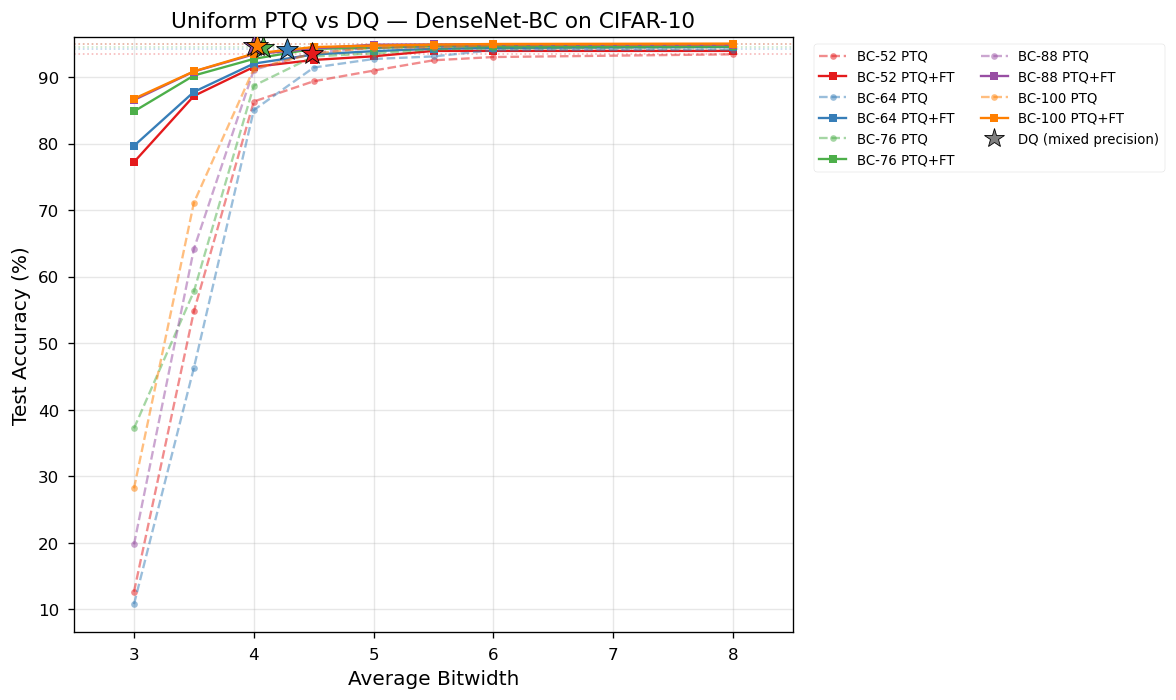

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

for m in MODELS:
    ptq = ptq_data[m]
    bits = [u["bits"] for u in ptq["uniform"]]
    acc_ptq = [u["accuracy"] for u in ptq["uniform"]]
    acc_ft = [u["accuracy_ft"] for u in ptq["uniform"]]
    color = MODEL_COLORS[m]
    label = MODEL_LABELS[m]
    
    # PTQ (dashed)
    ax.plot(bits, acc_ptq, "--o", color=color, markersize=4, alpha=0.5,
            label=f"{label} PTQ")
    # PTQ + FT (solid)
    ax.plot(bits, acc_ft, "-s", color=color, markersize=5,
            label=f"{label} PTQ+FT")
    
    # Float32 baseline
    ax.axhline(y=ptq["float32_accuracy"], color=color, linestyle=":",
               alpha=0.3, linewidth=1)
    
    # DQ point
    s = dq_summary[m]
    ax.plot(s["avg_hard"], s["best_acc"], "*", color=color,
            markersize=14, markeredgecolor="black", markeredgewidth=0.5,
            zorder=10)

# DQ legend entry (single)
ax.plot([], [], "*", color="gray", markersize=12, markeredgecolor="black",
        markeredgewidth=0.5, label="DQ (mixed precision)")

ax.set_xlabel("Average Bitwidth")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Uniform PTQ vs DQ — DenseNet-BC on CIFAR-10")
ax.set_xlim(2.5, 8.5)
ax.set_ylim(None, 96)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Graph 2: Accuracy Drop vs Bitwidth — Normalized Comparison

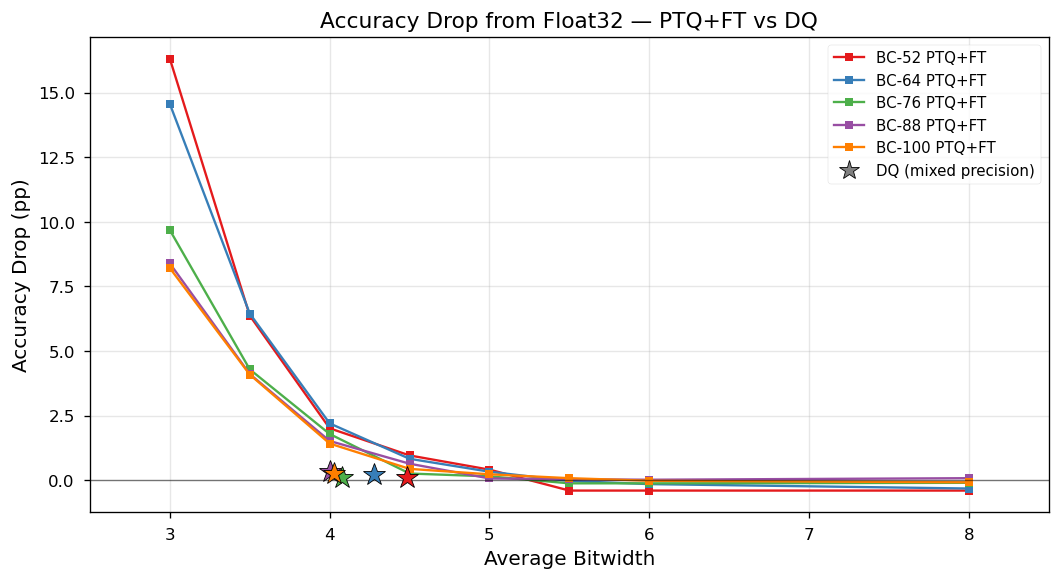

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

for m in MODELS:
    ptq = ptq_data[m]
    f32 = ptq["float32_accuracy"]
    bits = [u["bits"] for u in ptq["uniform"]]
    drop_ft = [f32 - u["accuracy_ft"] for u in ptq["uniform"]]
    color = MODEL_COLORS[m]
    
    ax.plot(bits, drop_ft, "-s", color=color, markersize=5,
            label=f"{MODEL_LABELS[m]} PTQ+FT")
    
    # DQ point
    s = dq_summary[m]
    dq_drop = f32 - s["best_acc"]
    ax.plot(s["avg_hard"], dq_drop, "*", color=color,
            markersize=14, markeredgecolor="black", markeredgewidth=0.5,
            zorder=10)

ax.plot([], [], "*", color="gray", markersize=12, markeredgecolor="black",
        markeredgewidth=0.5, label="DQ (mixed precision)")

ax.axhline(y=0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Average Bitwidth")
ax.set_ylabel("Accuracy Drop (pp)")
ax.set_title("Accuracy Drop from Float32 — PTQ+FT vs DQ")
ax.set_xlim(2.5, 8.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Graph 3: Split PTQ Heatmaps — W/A Bitwidth Asymmetry

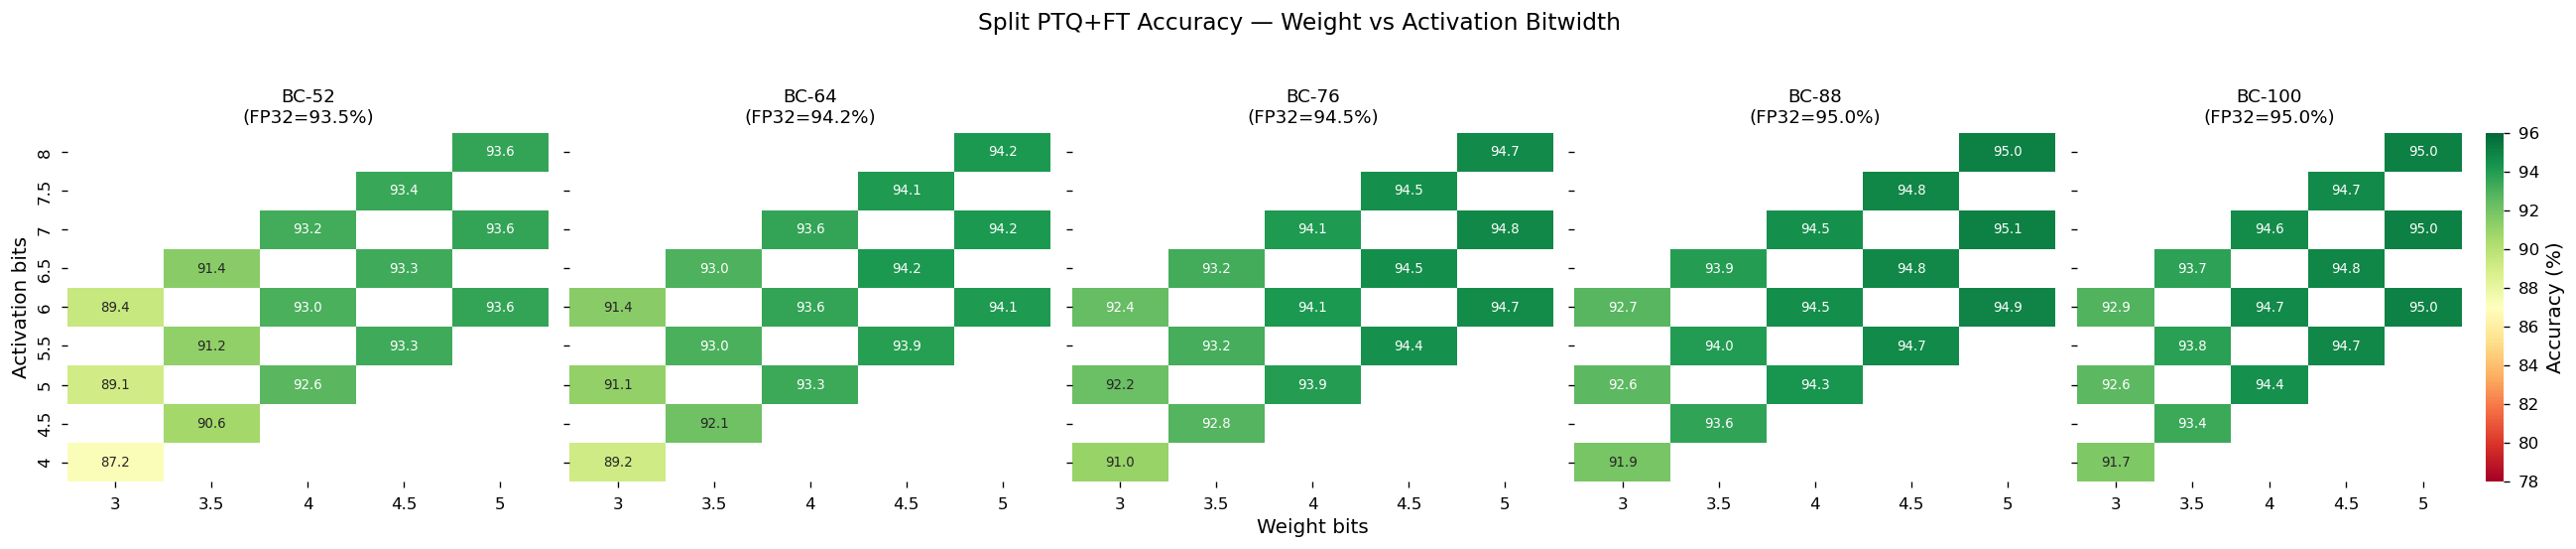

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    ptq = ptq_data[m]
    split = ptq["split"]
    
    # Get unique w_bits and a_bits
    w_bits_all = sorted(set(s["w_bits"] for s in split))
    a_bits_all = sorted(set(s["a_bits"] for s in split))
    
    # Build matrix
    matrix = np.full((len(a_bits_all), len(w_bits_all)), np.nan)
    for s in split:
        wi = w_bits_all.index(s["w_bits"])
        ai = a_bits_all.index(s["a_bits"])
        matrix[ai, wi] = s["accuracy_ft"]
    
    sns.heatmap(
        matrix, ax=ax, annot=True, fmt=".1f", cmap="RdYlGn",
        xticklabels=[str(b) for b in w_bits_all],
        yticklabels=[str(b) for b in a_bits_all],
        vmin=78, vmax=96,
        cbar=idx == len(MODELS) - 1,
        cbar_kws={"label": "Accuracy (%)"} if idx == len(MODELS) - 1 else {},
        annot_kws={"size": 8},
    )
    ax.set_title(f"{MODEL_LABELS[m]}\n(FP32={ptq['float32_accuracy']:.1f}%)", fontsize=11)
    ax.set_xlabel("Weight bits" if idx == 2 else "")
    if idx == 0:
        ax.set_ylabel("Activation bits")
    ax.invert_yaxis()

fig.suptitle("Split PTQ+FT Accuracy — Weight vs Activation Bitwidth", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Graph 4: Fine-tuning Improvement by Bitwidth

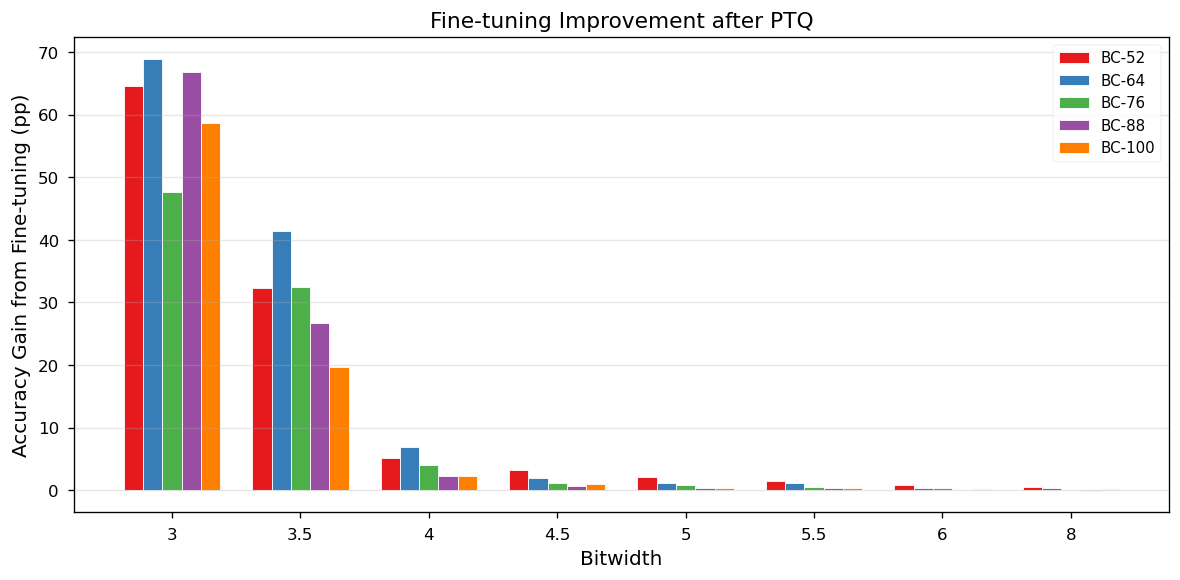

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

bits_list = [u["bits"] for u in ptq_data["52"]["uniform"]]
x = np.arange(len(bits_list))
width = 0.15
offsets = np.linspace(-2 * width, 2 * width, len(MODELS))

for i, m in enumerate(MODELS):
    ptq = ptq_data[m]
    gains = [u["accuracy_ft"] - u["accuracy"] for u in ptq["uniform"]]
    ax.bar(x + offsets[i], gains, width, color=MODEL_COLORS[m],
           label=MODEL_LABELS[m], edgecolor="white", linewidth=0.5)

ax.set_xlabel("Bitwidth")
ax.set_ylabel("Accuracy Gain from Fine-tuning (pp)")
ax.set_title("Fine-tuning Improvement after PTQ")
ax.set_xticks(x)
ax.set_xticklabels([str(b) for b in bits_list])
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Graph 5: DQ Per-layer Bitwidth Distribution (Soft Bitwidth Heatmap)

/var/folders/7m/_s2dd8053g97sjss_c0260mc0000gn/T/ipykernel_99424/3982484872.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


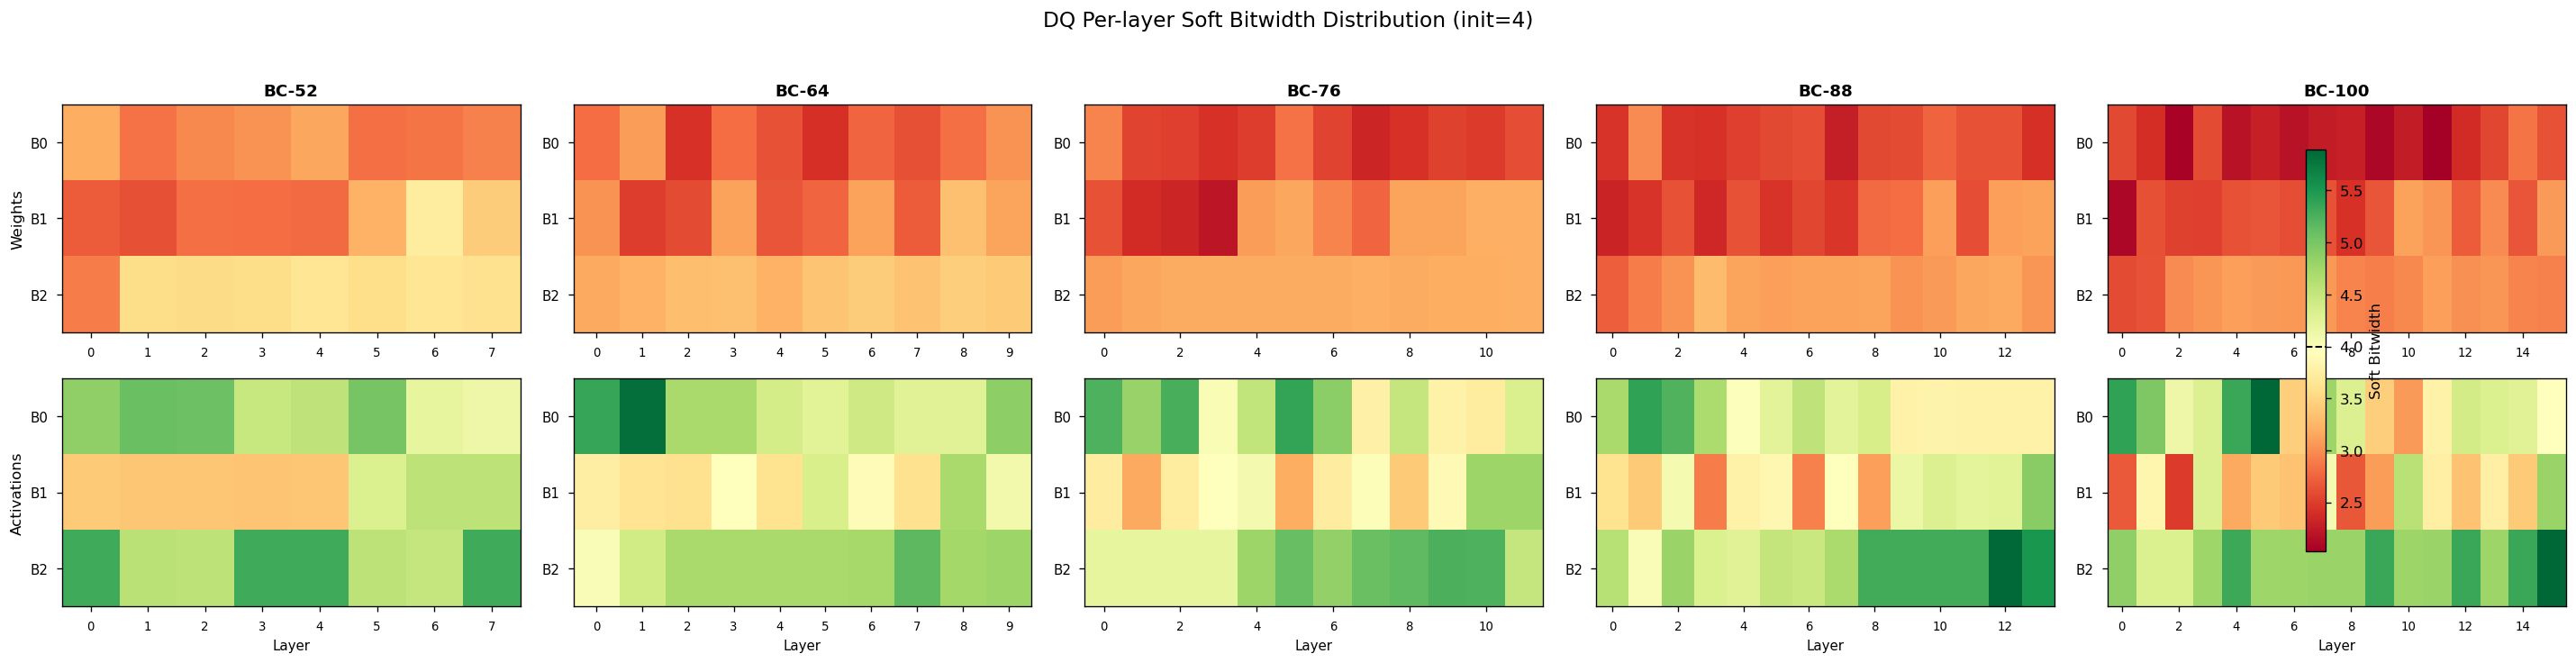

In [15]:
N_BLOCKS = 3
LAYERS_PER_MODEL = {"52": 8, "64": 10, "76": 12, "88": 14, "100": 16}

def build_heatmap_data(bitwidths, n_layers):
    """Build weight and activation heatmaps from per-layer bitwidths."""
    w_map = np.full((N_BLOCKS, n_layers), np.nan)
    act_map = np.full((N_BLOCKS, n_layers), np.nan)
    
    for name, info in bitwidths.items():
        match = re.match(
            r"blocks\.(\d+)\.layers\.(\d+)\.(dq_w1|dq_w2|dq_input_act|dq_mid_act)", name
        )
        if not match:
            continue
        b, l, qtype = int(match.group(1)), int(match.group(2)), match.group(3)
        bw = info["soft_bitwidth"]
        if qtype in ("dq_w1", "dq_w2"):
            w_map[b, l] = bw if np.isnan(w_map[b, l]) else (w_map[b, l] + bw) / 2
        else:
            act_map[b, l] = bw if np.isnan(act_map[b, l]) else (act_map[b, l] + bw) / 2
    
    return w_map, act_map


fig, axes = plt.subplots(2, 5, figsize=(24, 6))

# Compute global vmin/vmax across all models
global_vals = []
for m in MODELS:
    w, a = build_heatmap_data(dq_bitwidths[m], LAYERS_PER_MODEL[m])
    global_vals.extend(w[~np.isnan(w)].tolist())
    global_vals.extend(a[~np.isnan(a)].tolist())
vmin, vmax = min(global_vals), max(global_vals)

for col, m in enumerate(MODELS):
    n_layers = LAYERS_PER_MODEL[m]
    w_map, act_map = build_heatmap_data(dq_bitwidths[m], n_layers)
    
    for row, (data, title) in enumerate([(w_map, "Weights"), (act_map, "Activations")]):
        ax = axes[row, col]
        im = ax.imshow(
            data, aspect="auto", cmap="RdYlGn",
            vmin=vmin, vmax=vmax, interpolation="nearest",
        )
        ax.set_yticks(range(N_BLOCKS))
        ax.set_yticklabels([f"B{i}" for i in range(N_BLOCKS)], fontsize=9)
        ax.set_xticks(range(0, n_layers, max(1, n_layers // 6)))
        ax.set_xticklabels(range(0, n_layers, max(1, n_layers // 6)), fontsize=8)
        
        if row == 0:
            ax.set_title(f"{MODEL_LABELS[m]}", fontsize=11, fontweight="bold")
        if row == 1:
            ax.set_xlabel("Layer", fontsize=9)
        if col == 0:
            ax.set_ylabel(title, fontsize=10)

# Shared colorbar
cbar = fig.colorbar(im, ax=axes, fraction=0.01, pad=0.02)
cbar.set_label("Soft Bitwidth", fontsize=10)
cbar.ax.axhline(4.0, color="black", linewidth=1.2, linestyle="--")

fig.suptitle("DQ Per-layer Soft Bitwidth Distribution (init=4)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Graph 6: DQ vs PTQ — Direct Comparison at ~4-bit Budget

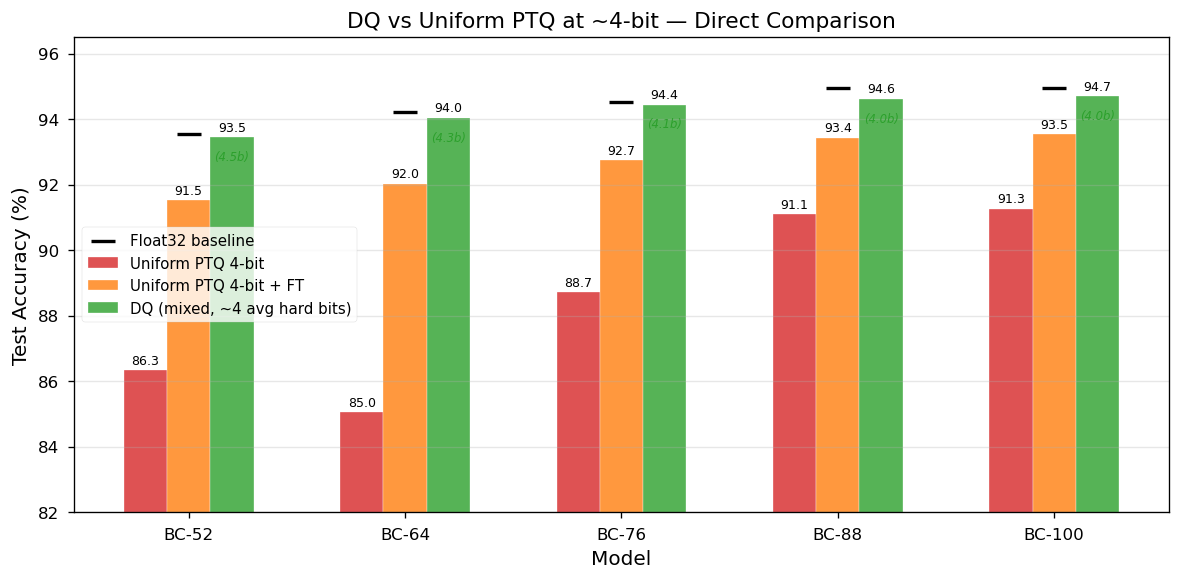

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(MODELS))
width = 0.2

ptq4_acc = []
ptq4_ft_acc = []
dq_acc = []
f32_acc = []

for m in MODELS:
    ptq = ptq_data[m]
    u4 = next(u for u in ptq["uniform"] if u["bits"] == 4)
    ptq4_acc.append(u4["accuracy"])
    ptq4_ft_acc.append(u4["accuracy_ft"])
    dq_acc.append(dq_summary[m]["best_acc"])
    f32_acc.append(ptq["float32_accuracy"])

bars1 = ax.bar(x - width, ptq4_acc, width, label="Uniform PTQ 4-bit",
               color="#d62728", alpha=0.8, edgecolor="white")
bars2 = ax.bar(x, ptq4_ft_acc, width, label="Uniform PTQ 4-bit + FT",
               color="#ff7f0e", alpha=0.8, edgecolor="white")
bars3 = ax.bar(x + width, dq_acc, width, label="DQ (mixed, ~4 avg hard bits)",
               color="#2ca02c", alpha=0.8, edgecolor="white")

# Float32 reference markers
ax.scatter(x, f32_acc, marker="_", s=200, color="black", zorder=10,
           linewidths=2, label="Float32 baseline")

# Value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{h:.1f}",
                ha="center", va="bottom", fontsize=7.5)

# DQ avg bitwidth annotation
for i, m in enumerate(MODELS):
    ax.text(x[i] + width, dq_acc[i] - 0.7,
            f"({dq_summary[m]['avg_hard']:.1f}b)",
            ha="center", fontsize=7, color="#2ca02c", fontstyle="italic")

ax.set_xlabel("Model")
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("DQ vs Uniform PTQ at ~4-bit — Direct Comparison")
ax.set_xticks(x)
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS])
ax.set_ylim(82, 96.5)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## Graph 7: DQ Training Curves

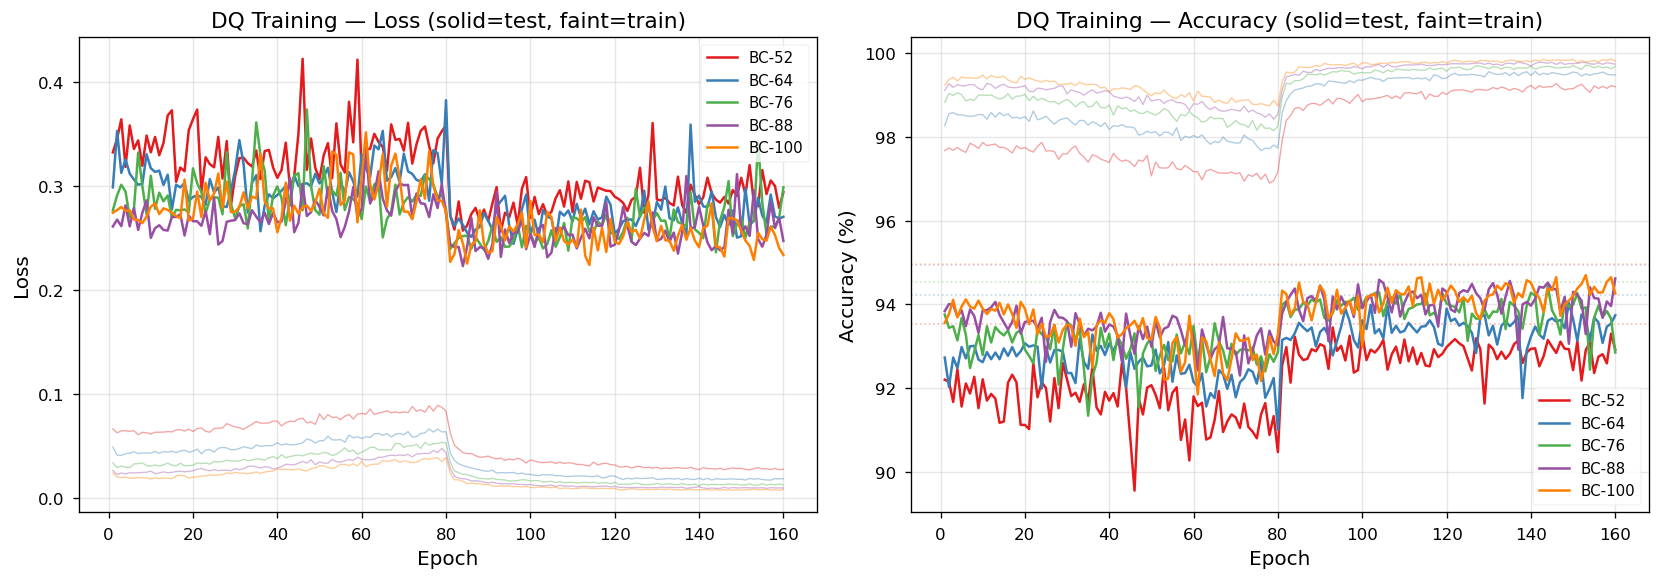

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss
ax = axes[0]
for m in MODELS:
    h = dq_history[m]
    epochs = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs, h["train_loss"], "-", color=MODEL_COLORS[m], alpha=0.4, linewidth=0.8)
    ax.plot(epochs, h["test_loss"], "-", color=MODEL_COLORS[m], linewidth=1.5,
            label=f"{MODEL_LABELS[m]}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("DQ Training — Loss (solid=test, faint=train)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: Accuracy
ax = axes[1]
for m in MODELS:
    h = dq_history[m]
    epochs = range(1, len(h["test_acc"]) + 1)
    ax.plot(epochs, h["train_acc"], "-", color=MODEL_COLORS[m], alpha=0.4, linewidth=0.8)
    ax.plot(epochs, h["test_acc"], "-", color=MODEL_COLORS[m], linewidth=1.5,
            label=f"{MODEL_LABELS[m]}")
    # Float32 baseline
    ax.axhline(y=dq_summary[m]["float32"], color=MODEL_COLORS[m],
               linestyle=":", alpha=0.3, linewidth=1)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy (%)")
ax.set_title("DQ Training — Accuracy (solid=test, faint=train)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()